# Pass Clustering & Team Playing Style Visualisation  

**Competition Focus:** La Liga - 2015/16 Season  
**Dataset:** StatsBomb Open Data (free event data repository)  
**Purpose:** Build pass clustering visualisations that reveal team playing styles, using event data to identify recurring passing patterns and present them in an intuitive, insight-driven format.  
**Methods:** Feature engineering, unsupervised learning (K-Means clustering), distributional analysis, z-score normalisation, and visualisation using representative pass trajectories.  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)  
**Medium Articles:**  _TBC_

**Notebook first written:** `14/04/2026`  
**Last updated:** `16/04/2026`  

> This notebook presents a step-by-step approach to building pass clustering visualisations using event data from the 2015/16 La Liga season. Each pass is represented by its start and end coordinates and grouped into clusters using K-Means, allowing recurring “pass types” to emerge from the data.  
>
> To make these patterns interpretable at team level, cluster usage is aggregated and compared to league averages using z-scores, highlighting which passing behaviours are over- or under-represented.  
>
> The approach is applied across multiple contexts, including all passes, own half build-up, and defensive third build-up, enabling a structured view of how teams construct possession in different phases of play.  
>
> The objective is not to evaluate performance, but to demonstrate how clustering and visualisation techniques can be combined to better understand and communicate patterns in football data.  

  
---------------------

## 1. Packages and Configuration

In [1]:
# Standard library
import math
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# Football data||
from statsbombpy import sb

# Machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Utilities
from tqdm import tqdm

warnings.filterwarnings("ignore", message="credentials were not supplied")

## Check Barcelona Match Data

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Call statsbomb API to get all free competitions, then check Women's comps
free_comps = sb.competitions()
laliga_comps = free_comps[
    (free_comps['competition_gender'] == 'male') & 
    (free_comps['competition_name'] == 'La Liga')
]

laliga_comps

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386
39,11,42,Spain,La Liga,male,False,False,2019/2020,2024-12-16T16:51:06.833054,2021-06-13T16:17:31.694,None,2024-12-16T16:51:06.833054
40,11,4,Spain,La Liga,male,False,False,2018/2019,2024-09-22T18:50:23.364757,2021-07-09T14:53:22.103024,None,2024-09-22T18:50:23.364757
41,11,1,Spain,La Liga,male,False,False,2017/2018,2025-07-14T10:01:16.674864,2021-06-13T16:17:31.694,None,2025-07-14T10:01:16.674864
42,11,2,Spain,La Liga,male,False,False,2016/2017,2025-03-09T16:03:54.962718,2021-06-13T16:17:31.694,None,2025-03-09T16:03:54.962718
43,11,27,Spain,La Liga,male,False,False,2015/2016,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
44,11,26,Spain,La Liga,male,False,False,2014/2015,2025-06-24T13:39:01.068680,2021-06-13T16:17:31.694,None,2025-06-24T13:39:01.068680
45,11,25,Spain,La Liga,male,False,False,2013/2014,2025-06-24T09:52:44.048585,2021-06-13T16:17:31.694,None,2025-06-24T09:52:44.048585
46,11,24,Spain,La Liga,male,False,False,2012/2013,2025-06-24T13:53:14.047130,2021-06-13T16:17:31.694,None,2025-06-24T13:53:14.047130
47,11,23,Spain,La Liga,male,False,False,2011/2012,2025-06-24T13:38:10.764259,2021-06-13T16:17:31.694,None,2025-06-24T13:38:10.764259


In [3]:
# Prepare list to store match counts
match_counts = []

# Loop over each competition_id + season_id
for comp_id, season_id in zip(laliga_comps['competition_id'], laliga_comps['season_id']):
    # Count actual matches
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        matches_count = len(matches)
    except:
        matches_count = 0

    match_counts.append({
        'competition_id': comp_id,
        'season_id': season_id,
        'matches_count': matches_count
    })

# Convert to DataFrame
match_counts_df = pd.DataFrame(match_counts)

# Join metadata from men_comps
metadata_cols = ['competition_id', 'season_id', 'competition_name', 'season_name',
                 'match_updated', 'match_updated_360', 'match_available_360', 'match_available']
match_counts_df = match_counts_df.merge(laliga_comps[metadata_cols], on=['competition_id', 'season_id'], how='left')

# Sort by actual matches
match_counts_df.sort_values('matches_count', ascending=False, inplace=True)
match_counts_df.reset_index(drop=True, inplace=True)

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None )

match_counts_df["season_start"] = (
    match_counts_df["season_name"]
    .str.split("/")
    .str[0]
    .astype(int)
)

match_counts_df[match_counts_df['competition_id'] == 11
][['competition_id', 'competition_name', 'season_id', 'season_name', 'season_start',
   'matches_count']].sort_values(by='season_name')

,competition_id,competition_name,season_id,season_name,season_start,matches_count
17,11,La Liga,278,1973/1974,1973,1
16,11,La Liga,37,2004/2005,2004,7
15,11,La Liga,38,2005/2006,2005,17
14,11,La Liga,39,2006/2007,2006,26
13,11,La Liga,40,2007/2008,2007,28
12,11,La Liga,41,2008/2009,2008,31
4,11,La Liga,21,2009/2010,2009,35
9,11,La Liga,22,2010/2011,2010,33
2,11,La Liga,23,2011/2012,2011,37
10,11,La Liga,24,2012/2013,2012,32


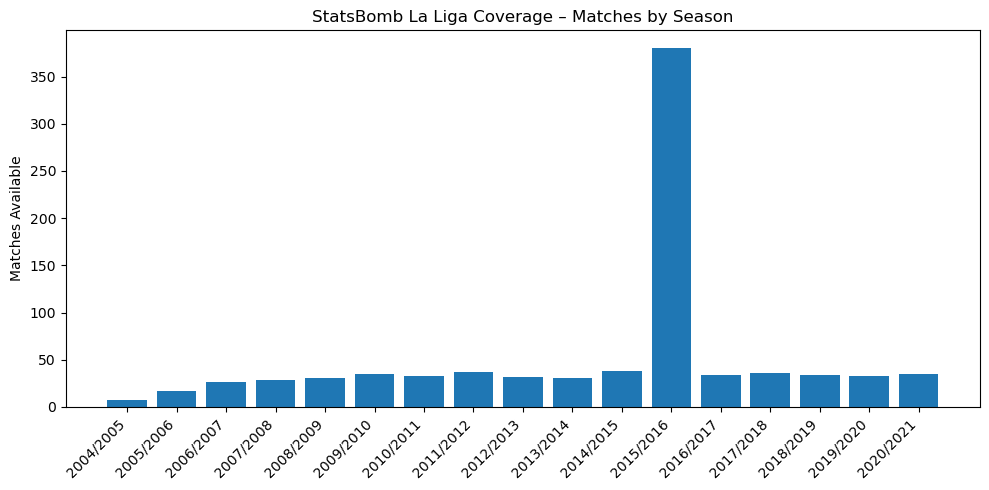

In [5]:
match_counts_df = match_counts_df[
    match_counts_df["season_start"] >= 2004
].sort_values(by="season_start")

plt.figure(figsize=(10, 5))
plt.bar(match_counts_df["season_name"], match_counts_df["matches_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Matches Available")
plt.title("StatsBomb La Liga Coverage – Matches by Season")
plt.tight_layout()
plt.show()

## 2. Load Competition, Match & Event Data

In [6]:
# Download Matches

leagues = list(zip(
    laliga_comps["competition_id"],
    laliga_comps["season_id"]
))

matches_df = pd.concat([
    sb.matches(competition_id=comp, season_id=season)
    for comp, season in leagues
], ignore_index=True)

len(matches_df)

868

In [7]:
matches_df.head()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,available,2023-07-25T03:54:59.280826,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2
1,3773565,2021-01-09,18:30:00.000,Spain - La Liga,2020/2021,Granada,Barcelona,0,4,available,available,2023-07-25T03:51:37.437064,2023-07-25T04:30:16.058384,18,Regular Season,Estadio Nuevo Los Cármenes,Ricardo De Burgos Bengoetxea,Diego Martínez Penas,Ronald Koeman,1.1.0,2,2
2,3773457,2021-05-16,18:30:00.000,Spain - La Liga,2020/2021,Barcelona,Celta Vigo,1,2,available,available,2022-12-02T09:26:39.496362,2023-04-27T23:03:53.506485,37,Regular Season,Spotify Camp Nou,NaN,Ronald Koeman,Eduardo Germán Coudet,1.1.0,2,2
3,3773631,2021-02-07,21:00:00.000,Spain - La Liga,2020/2021,Real Betis,Barcelona,2,3,available,available,2023-07-25T03:47:44.278651,2023-07-25T03:56:34.733180,22,Regular Season,Estadio Benito Villamarín,NaN,Manuel Luis Pellegrini Ripamonti,Ronald Koeman,1.1.0,2,2
4,3773665,2021-03-06,21:00:00.000,Spain - La Liga,2020/2021,Osasuna,Barcelona,0,2,available,available,2022-12-02T08:46:42.897589,2023-04-28T02:57:03.412841,26,Regular Season,Estadio El Sadar,Guillermo Cuadra Fernández,Jagoba Arrasate Elustondo,Ronald Koeman,1.1.0,2,2


In [8]:
# Extract Pass Events

CACHE_DIR = Path("statsbomb_cache/events_15_16")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def load_events(match_id):
    cache_file = CACHE_DIR / f"{match_id}.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)

    events = sb.events(match_id=match_id)
    events.to_parquet(cache_file)
    return events

all_passes = []

for match_id in tqdm(matches_df["match_id"], desc="Extracting passes"):
    events = load_events(match_id)
    passes = events[events["type"] == "Pass"].copy()
    passes["match_id"] = match_id
    all_passes.append(passes)

passes_df = pd.concat(all_passes, ignore_index=True)

Extracting passes: 100%|██████████| 868/868 [00:16<00:00, 53.17it/s]


In [9]:
matches_meta = matches_df[[
    "match_id",
    "season",
    "competition",
    "home_team",
    "away_team"
]].copy()

passes_df = passes_df.merge(matches_meta, on="match_id", how="left")

In [10]:
len(passes_df)

880223

In [11]:
passes_df.to_csv("Datasets/passes_laliga_statsbomb_all.csv", index=False)

In [2]:
passes_df = pd.read_csv("Datasets/passes_laliga_statsbomb_all.csv")

C:\Users\vicky\AppData\Local\Temp\ipykernel_35992\953162522.py:1: DtypeWarning: Columns (38,99) have mixed types. Specify dtype option on import or set low_memory=False.
  passes_df = pd.read_csv("Datasets/passes_laliga_statsbomb_all.csv")


## 3. Data Cleaning & Feature Engineering

In [3]:
passes = passes_df.dropna(axis=1, how="all").copy()

def extract_coords(col):
    x = pd.to_numeric(col.astype(str).str.strip("[]").str.split().str[0], errors="coerce")
    y = pd.to_numeric(col.astype(str).str.strip("[]").str.split().str[1], errors="coerce")
    return x, y

passes["start_x"], passes["start_y"] = extract_coords(passes["location"])
passes["end_x"], passes["end_y"] = extract_coords(passes["pass_end_location"])

FEATURES = ["start_x", "start_y", "end_x", "end_y"]

# Remove unwanted passes
passes = passes[passes["pass_outcome"] != "Injury Clearance"].copy()

# Drop NaNs in clustering features
passes = passes.dropna(subset=FEATURES).copy()

# Fix pitch bounds

for col, max_val in [("start_x", 120), ("end_x", 120), ("start_y", 80), ("end_y", 80)]:
    passes[col] = passes[col].clip(lower=0, upper=max_val)

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None )

passes.head()

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_goal_assist,pass_straight,pass_miscommunication,season,competition,home_team,away_team,start_x,start_y,end_x,end_y
0,NaN,0.963571,208f072d-cffa-4575-bd73-e9e9384c8fe1,5,[61. 40.1],3773386,0,NaN,NaN,NaN,2.692596,NaN,Left Foot,NaN,NaN,NaN,[50. 45.4],Ground Pass,NaN,12.210241,NaN,NaN,NaN,Sergio Busquets i Burgos,5203.0,NaN,NaN,NaN,NaN,Kick Off,1,From Kick Off,Antoine Griezmann,5487.0,Center Forward,2,Barcelona,217,['1b0529a5-c699-44e4-b534-80a48503d3a8'],0,Barcelona,217,00:00:00.689,Pass,NaN,NaN,NaN,NaN,2020/2021,Spain - La Liga,Deportivo Alavés,Barcelona,61.0,40.1,50.0,45.4
1,NaN,0.998827,e1f11e14-fb24-4c82-868f-507385122b9c,7,[49.4 44.9],3773386,0,NaN,NaN,NaN,-1.720006,NaN,Right Foot,NaN,NaN,NaN,[47.1 29.6],Ground Pass,NaN,15.471910,NaN,NaN,NaN,Frenkie de Jong,8118.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Sergio Busquets i Burgos,5203.0,Right Defensive Midfield,2,Barcelona,217,['b9c89821-9722-4c12-ada7-e1d09cc10a89'],1,Barcelona,217,00:00:01.653,Pass,NaN,NaN,NaN,NaN,2020/2021,Spain - La Liga,Deportivo Alavés,Barcelona,49.4,44.9,47.1,29.6
2,NaN,1.263872,4d801bc4-907a-4474-9620-7c6ca2610ea7,10,[48.1 29.6],3773386,0,NaN,NaN,NaN,2.111216,NaN,Right Foot,NaN,NaN,NaN,[35.5 50.6],Ground Pass,NaN,24.489998,NaN,NaN,NaN,Gerard Piqué Bernabéu,5213.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Frenkie de Jong,8118.0,Left Defensive Midfield,2,Barcelona,217,['c4d7296a-bcea-4f7d-bcc9-c1bf5dae6fe7'],5,Barcelona,217,00:00:05.344,Pass,NaN,NaN,NaN,NaN,2020/2021,Spain - La Liga,Deportivo Alavés,Barcelona,48.1,29.6,35.5,50.6
3,NaN,1.331522,72a0c004-6d76-4ea8-b892-0f7881be9320,13,[44.3 50.2],3773386,0,NaN,NaN,NaN,-1.730403,NaN,Right Foot,NaN,NaN,NaN,[41. 29.7],Ground Pass,NaN,20.763910,NaN,NaN,NaN,Clément Lenglet,6826.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Gerard Piqué Bernabéu,5213.0,Right Center Back,2,Barcelona,217,['3d285d86-2ff7-45c9-8447-825fcbe5b5bc'],10,Barcelona,217,00:00:10.283,Pass,NaN,NaN,NaN,NaN,2020/2021,Spain - La Liga,Deportivo Alavés,Barcelona,44.3,50.2,41.0,29.7
4,NaN,1.004666,ba9d104d-bddd-44bd-b156-991e7f5f0344,16,[49. 28.7],3773386,0,NaN,NaN,NaN,0.499347,NaN,Left Foot,NaN,NaN,NaN,[57.8 33.5],Ground Pass,NaN,10.023972,NaN,NaN,NaN,Sergio Busquets i Burgos,5203.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Clément Lenglet,6826.0,Left Center Back,2,Barcelona,217,['ff18cfb6-31ba-4e71-bc9f-5fe07a9d2ceb'],14,Barcelona,217,00:00:14.201,Pass,NaN,NaN,NaN,NaN,2020/2021,Spain - La Liga,Deportivo Alavés,Barcelona,49.0,28.7,57.8,33.5


In [27]:
# BUILD BARÇA BY SEASON (CRITICAL STEP)

barca = passes[passes["team"] == "Barcelona"].copy()
barca["team_season"] = "Barcelona " + barca["season"]

## 4. Clustering Framework (Reusable)

In [28]:
FEATURES = ["start_x", "start_y", "end_x", "end_y"]

def run_clustering(df, n_clusters=50, seed=14):
    scaler = StandardScaler()
    X = scaler.fit_transform(df[FEATURES])

    model = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    df = df.copy()
    df["cluster"] = model.fit_predict(X)

    return df, scaler, model

## 5. Cluster Analysis Utilities

In [18]:
def compute_zscores(df, cluster_col):
    team_cluster = (
        df.groupby(["team_season", cluster_col])
        .size()
        .reset_index(name="count")
    )

    team_total = df.groupby("team_season").size().reset_index(name="total")

    dist = team_cluster.merge(team_total, on="team_season")
    dist["prop"] = dist["count"] / dist["total"]

    league_avg = dist.groupby(cluster_col)["prop"].mean()
    league_std = dist.groupby(cluster_col)["prop"].std()

    dist["z"] = (
        (dist["prop"] - dist[cluster_col].map(league_avg)) /
        (dist[cluster_col].map(league_std) + 1e-6)
    )

    return dist

## 6. Representative Passes & Descriptions

In [21]:
def representative_passes(df_cluster, scaler, n=30):
    X = scaler.transform(df_cluster[FEATURES])
    centroid = X.mean(axis=0)

    dist = np.linalg.norm(X - centroid, axis=1)
    df_cluster = df_cluster.copy()
    df_cluster["dist"] = dist

    return df_cluster.sort_values("dist").head(n)

## 7. Visualisation Functions

In [29]:
pitch = Pitch(pitch_type="statsbomb", line_color="black")

def plot_team(ax, df, dist, scaler, team, display_name=None, top_n=5, show_descriptions=False):
    team_df = df[df["team"] == team]

    # --- handle z column naming ---
    z_col = "z_score" if "z_score" in dist.columns else "z"

    top_clusters = (
        dist[dist["team"] == team]
        .sort_values(z_col, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    cmap = plt.colormaps["tab10"]

    # --- stable cluster-color mapping ---
    cluster_info = []
    for i, row in enumerate(top_clusters.itertuples()):
        cluster_info.append({
            "cluster": row.cluster,
            "color": cmap(i % 10),
            "idx": i + 1
        })

    # --- plot in reverse so #1 is on top ---
    for info in reversed(cluster_info):
        cluster_df = team_df[team_df["cluster"] == info["cluster"]]
        reps = representative_passes(cluster_df, scaler)

        for _, p in reps.iterrows():
            ax.arrow(
                p["start_x"], p["start_y"],
                p["end_x"] - p["start_x"],
                p["end_y"] - p["start_y"],
                head_width=1.2,
                head_length=2,
                linewidth=1.3,
                color=info["color"],
                alpha=0.4
            )

    # --- legend (original order) ---
    descriptions = [(c["idx"], c["color"]) for c in cluster_info]

    # --- title (with optional position) ---
    title = display_name if display_name is not None else team
    ax.set_title(title, pad=6, fontweight="bold")

    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])

    y = -0.02

    if show_descriptions:
        for i, (idx, color) in enumerate(descriptions):
            ax.text(
                0.5,
                y - i * 0.06,
                f"➜ {idx}",
                transform=ax.transAxes,
                fontsize=9,
                color=color,
                ha="center",
                va="top"
            )
    else:
        x_positions = np.linspace(0.2, 0.8, len(descriptions))

        for x, (idx, color) in zip(x_positions, descriptions):
            ax.text(
                x,
                y,
                f"➜ {idx}",
                transform=ax.transAxes,
                fontsize=11,
                color=color,
                ha="center",
                va="top"
            )


def plot_grid(df, dist, scaler, cluster_col, title, n_cols=4):

    teams = sorted(df["team_season"].unique())

    n_rows = math.ceil(len(teams) / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(18, 4 * n_rows),
        gridspec_kw={'hspace': 0.08, 'wspace': 0.05}
    )

    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.92)

    for i, team in enumerate(teams):
        pitch.draw(ax=axes[i])

        plot_team(
            axes[i],
            df,
            dist,
            scaler,
            team,
            cluster_col,
            display_name=f"{i+1}. {team}"
        )

    # turn off extras
    for j in range(len(teams), len(axes)):
        axes[j].axis("off")

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

## 8. Applications

In [30]:
# ALL PASSES

# MODEL 1 — GLOBAL FOOTBALL MODEL

df_global, scaler_global, kmeans_global = run_clustering(passes)

X_global = scaler_global.transform(barca[FEATURES])
barca["cluster_global"] = kmeans_global.predict(X_global)

dist_global = compute_zscores(barca, "cluster_global")

plot_grid(
    barca,
    dist_global,
    scaler_global,
    "Barcelona Season Profiles | GLOBAL Model"
)

TypeError: plot_grid() missing 1 required positional argument: 'title'

In [ ]:
# MODEL 2 — 2015/16 CONTEXT MODEL

passes_1516 = passes[passes["season"] == "2015/2016"].copy()

df_1516, scaler_1516, kmeans_1516 = run_clustering(passes_1516)

X_1516 = scaler_1516.transform(barca[FEATURES])
barca["cluster_1516"] = kmeans_1516.predict(X_1516)

dist_1516 = compute_zscores(barca, "cluster_1516")

plot_grid(
    barca,
    dist_1516,
    scaler_1516,
    "Barcelona Season Profiles | 2015/16 Tactical Model"
)

In [ ]:
# OWN HALF

own_half = passes[passes["start_x"] <= 60].copy()

df_own, scaler = run_clustering(own_half)
dist_own = compute_zscores(df_own)

plot_grid(
    df_own,
    dist_own,
    scaler,
    "Team Passing Style Clusters (Own Half) | La Liga 2015/16 | Top 5 Clusters (Z-Score vs League)",
    save_path="Images and others/team_clusters_laliga1516_ownhalf.png"
)

In [ ]:
# DEFENSIVE THIRD

def_third = passes[passes["start_x"] <= 40].copy()

df_def, scaler = run_clustering(def_third)
dist_def = compute_zscores(df_def)

plot_grid(
    df_def,
    dist_def,
    scaler,
    "Team Passing Style Clusters (Defensive Third) | La Liga 2015/16 | Top 5 Clusters (Z-Score vs League)",
    save_path="Images and others/team_clusters_laliga1516_ownthird.png"
)